<a href="https://colab.research.google.com/github/ghobrosg/codecarbon-demo/blob/main/docs/tutorials/first-tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Your First Emissions Tracking

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mlco2/codecarbon/blob/master/docs/tutorials/first-tracking.ipynb)

This tutorial walks you through tracking your first carbon emissions with CodeCarbon.
By the end, you will have:

1. Installed CodeCarbon
2. Tracked emissions from a simple computation
3. Inspected the results

---

## Step 1: Install CodeCarbon

In [34]:
!pip install codecarbon

## Step 2: Track emissions from a computation

The simplest way to use CodeCarbon is as a **context manager**. Everything inside the `with` block is tracked.

In [35]:
import time
import random
import pandas as pd
import matplotlib.pyplot as plt

from codecarbon import EmissionsTracker

with EmissionsTracker(project_name="my-first-tracking") as tracker:
    # Simulate some computation
    total = 0
    for i in range(10_000_000):
        total += i

print(f"Computation result: {total}")

[codecarbon INFO @ 02:22:38] Emissions data (if any) will be saved to file /content/emissions.csv
[codecarbon INFO @ 02:22:38] >>> Tracker's metadata:
[codecarbon INFO @ 02:22:38]   Platform system: Linux-6.6.122+-x86_64-with-glibc2.39
[codecarbon INFO @ 02:22:38]   Python version: 3.13.15
[codecarbon INFO @ 02:22:38]   CodeCarbon version: 3.3.1
[codecarbon INFO @ 02:22:38]   Available RAM : 12.671 GB
[codecarbon INFO @ 02:22:38]   CPU count: 2 thread(s) in 1 physical CPU(s)
[codecarbon INFO @ 02:22:38]   CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon INFO @ 02:22:38]   GPU count: 0
[codecarbon INFO @ 02:22:38]   GPU model: 
[codecarbon INFO @ 02:22:38] Energy consumed for RAM : 0.000000 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 02:22:38] Delta energy consumed for CPU with cpu_load : 0.000000 kWh, power : 0.8341397504000001 W
[codecarbon INFO @ 02:22:38] Energy consumed for All CPU : 0.000000 kWh
[codecarbon INFO @ 02:22:38] 0.000000 kWh of electricity and 0.000000 L of water w

Computation result: 49999995000000


## Step 3: Inspect the results

CodeCarbon saved the emissions data to a CSV file. Let's take a look:

In [36]:
import pandas as pd

df = pd.read_csv("emissions.csv")
df[["project_name", "duration", "emissions", "emissions_rate", "cpu_power", "ram_power", "energy_consumed"]]

,project_name,duration,emissions,emissions_rate,cpu_power,ram_power,energy_consumed
0,my-first-tracking,2.025735,8.346275e-07,4.120122e-07,4.934683,10.0,0.000006
1,my-first-tracking,4.566810,2.540738e-06,5.563486e-07,3.734295,10.0,0.000018
2,my-first-tracking,4.183583,2.548518e-06,6.091712e-07,3.697114,10.0,0.000018
3,my-first-tracking,3.895278,2.133087e-06,5.476084e-07,2.930150,10.0,0.000015
4,my-first-tracking,4.006623,2.131089e-06,5.318916e-07,2.526110,10.0,0.000015
5,my-first-tracking,3.281709,1.708483e-06,5.206077e-07,2.505671,10.0,0.000012


You can also access the emissions data directly from the tracker object:

In [37]:
print(f"Total emissions: {tracker.final_emissions * 1000:.4f} g CO2eq")
print(f"Duration: {tracker.final_emissions_data.duration:.2f} seconds")
print(f"Energy consumed: {tracker.final_emissions_data.energy_consumed:.6f} kWh")

Total emissions: 0.0017 g CO2eq
Duration: 3.28 seconds
Energy consumed: 0.000012 kWh


In [38]:
def linear_search(arr, target):
    for i, value in enumerate(arr):
        if value == target:
            return i
    return -1


def binary_search(arr, target):
    left = 0
    right = len(arr) - 1

    while left <= right:
        mid = (left + right) // 2

        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return -1

In [39]:
def linear_search(arr, target):
    for i, value in enumerate(arr):
        if value == target:
            return i
    return -1


def binary_search(arr, target):
    left = 0
    right = len(arr) - 1

    while left <= right:
        mid = (left + right) // 2

        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return -1

In [40]:
input_sizes = [1_000, 5_000, 10_000, 25_000, 50_000]

results = []

for n in input_sizes:

    data = list(range(n))
    target = n - 1

    # Linear Search
    tracker = EmissionsTracker(
        project_name=f"Linear Search n={n}",
        save_to_file=False,
        log_level="error"
    )

    tracker.start()
    start = time.perf_counter()

    linear_search(data, target)

    linear_runtime = time.perf_counter() - start
    linear_emissions = tracker.stop()

    # Binary Search
    tracker = EmissionsTracker(
        project_name=f"Binary Search n={n}",
        save_to_file=False,
        log_level="error"
    )

    tracker.start()
    start = time.perf_counter()

    binary_search(data, target)

    binary_runtime = time.perf_counter() - start
    binary_emissions = tracker.stop()

    results.append({
        "Input Size": n,
        "Linear Runtime": linear_runtime,
        "Linear CO2e": linear_emissions,
        "Binary Runtime": binary_runtime,
        "Binary CO2e": binary_emissions
    })

scaling_df = pd.DataFrame(results)

scaling_df

[codecarbon WARNING @ 02:22:41] Multiple instances of codecarbon are allowed to run at the same time.


,Input Size,Linear Runtime,Linear CO2e,Binary Runtime,Binary CO2e
0,1000,0.000082,2.093243e-10,0.000012,1.856713e-10
1,5000,0.000699,1.616714e-10,0.000014,1.028578e-09
2,10000,0.001234,2.706311e-10,0.000014,2.383607e-10
3,25000,0.003319,2.257771e-09,0.000013,5.821492e-10
4,50000,0.009886,1.378955e-09,0.000015,1.796002e-09


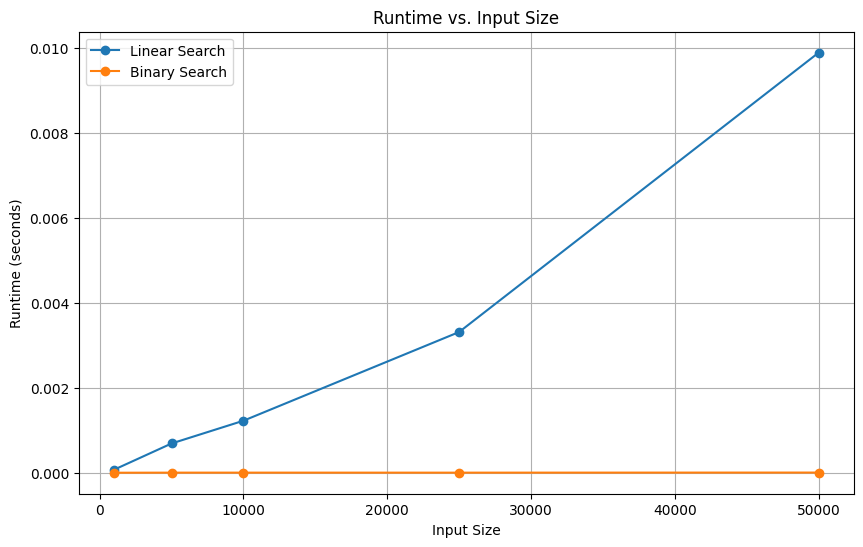

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    scaling_df["Input Size"],
    scaling_df["Linear Runtime"],
    marker="o",
    label="Linear Search"
)

plt.plot(
    scaling_df["Input Size"],
    scaling_df["Binary Runtime"],
    marker="o",
    label="Binary Search"
)

plt.xlabel("Input Size")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs. Input Size")
plt.legend()
plt.grid(True)

plt.show()

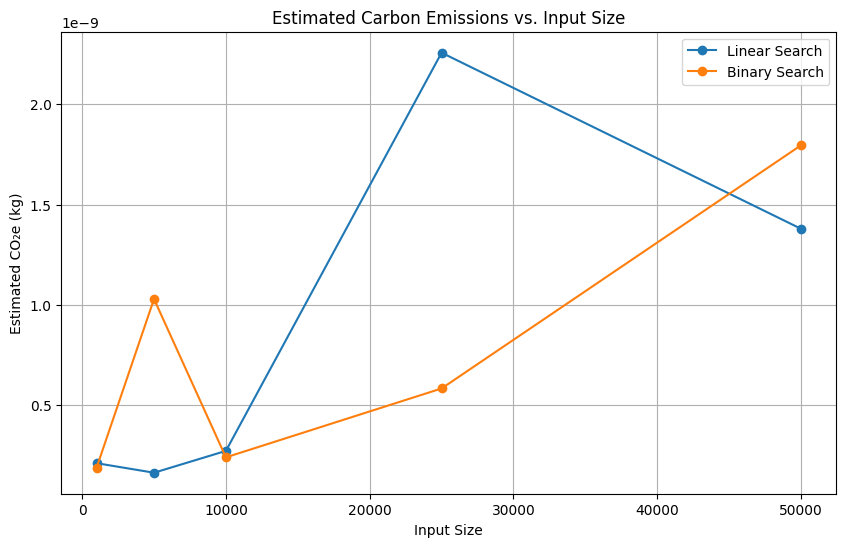

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    scaling_df["Input Size"],
    scaling_df["Linear CO2e"],
    marker="o",
    label="Linear Search"
)

plt.plot(
    scaling_df["Input Size"],
    scaling_df["Binary CO2e"],
    marker="o",
    label="Binary Search"
)

plt.xlabel("Input Size")
plt.ylabel("Estimated CO₂e (kg)")
plt.title("Estimated Carbon Emissions vs. Input Size")
plt.legend()
plt.grid(True)

plt.show()

## What's next?

- Try the [CodeCarbon Workshop notebook](https://github.com/mlco2/codecarbon/blob/master/examples/notebooks/codecarbon_workshop.ipynb) for a comprehensive hands-on experience
- Learn about [CLI tracking](cli.md) to monitor without code changes
- Explore all [Python API options](python-api.md) (decorators, explicit objects, offline mode)
- See the full [API Reference](../reference/api.md) for all configuration parameters